In [11]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    # plt.style.use('belle2_serif')
    plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    if data_df!=None:
        # Data points
        data_hist, _ = np.histogram(data_df[var], bins=xbins)
        ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
        
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    ax.set_ylim(0,3000)
    ax.legend(loc="upper right", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


In [13]:
def do_BCS(var='BDT', df=None, ascending=False):
    if df is None:
        df = pd.DataFrame()
    df_copied = df.copy()
    df_copied['rank_study'] = df_copied.groupby(
        ['__experiment__', '__run__', '__event__', '__production__']
    )[var].rank(ascending=ascending, method='first')
    
    final_df = df_copied.query("rank_study == 1").drop(columns='rank_study')
    return final_df

In [14]:
def do_random_choice(var=None, df=None, random_state=251124):
    if df is None:
        df = pd.DataFrame()
    
    np.random.seed(random_state)
    
    # Group by the same columns as do_BCS and sample one row per group
    final_df = df.groupby(
        ['__experiment__', '__run__', '__event__', '__production__'], group_keys=False
    ).apply(lambda x: x.sample(n=1))
    
    return final_df

In [15]:
def do_random_choice_fast(df=None, random_state=251124):
    if df is None or df.empty:
        return pd.DataFrame()
    
    np.random.seed(random_state)
    
    # Add a random number column
    df_copied = df.copy()
    df_copied['_rand'] = np.random.rand(len(df_copied))
    
    # For each group, get the index of the row with max random number
    idx = df_copied.groupby(
        ['__experiment__', '__run__', '__event__', '__production__']
    )['_rand'].idxmax()
    
    final_df = df_copied.loc[idx].drop(columns='_rand')
    
    return final_df

In [16]:
def load_root_files(BCS_var, dir_topo_list, dir_list, tags, tree, cut, variables, bdt_cut):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        if tag != "ccbar":
            for d in dir_list:
                pattern = os.path.join(d,f"{tree}","min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
                # print(pattern)
                matched_files = glob.glob(pattern)
                matched_files.sort()
                file_map[tag].extend(matched_files)
        else:
            for d in dir_topo_list:
                path = os.path.join(d, f"standard.root")
                if os.path.exists(path):
                    file_map[tag].append(path)              
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")            


    dataframes = {}
    for tag in tags:
        # ccbar 분리
        if tag == "ccbar":
            if BCS_var == 'BDT':
                dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_8','nAllSigCascDcyBr_4','nAllSigCascDcyBr_10','nAllSigCascDcyBr_14','BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'Dp_chiProb':
                dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_8','nAllSigCascDcyBr_4','Dp_chiProb','nAllSigCascDcyBr_10','nAllSigCascDcyBr_14','BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'random':
                dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_8','nAllSigCascDcyBr_4','Dp_chiProb','nAllSigCascDcyBr_10','nAllSigCascDcyBr_14','BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]
            elif BCS_var == 'no_BCS':
                dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_8','nAllSigCascDcyBr_4','Dp_chiProb','nAllSigCascDcyBr_10','nAllSigCascDcyBr_14','BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']) for fp in file_map[tag]]                
            else:
                ValueError('Do correct BCS')
            
            df = pd.concat(dfs, ignore_index=True)
            # df["ds_weight"] *= 1/4  # Scale weights
            
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            df_bkg_comb = df.query("(nAllSigCascDcyBr_10 <= 0) and (nAllSigCascDcyBr_14 <= 0)").copy()
            # df_bkg_comb = df.query("(nAllSigCascDcyBr_3 <= 0) and (nAllSigCascDcyBr_7 <= 0)").copy()

            df_bkg_comb["ds_weight"] = df_bkg_comb["ds_weight"]
            df_bkg_comb.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_bkg_comb"] = df_bkg_comb.query(cut)
        else:
            if BCS_var == 'BDT':
                dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'Dp_chiProb':
                dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'random':
                dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]
            elif BCS_var == 'no_BCS':
                dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']) for fp in file_map[tag]]                
            else:
                ValueError('Do correct BCS')
            # dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables +  ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            # dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            # dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]

            df = pd.concat(dfs, ignore_index=True)
            # df["ds_weight"] *= 1/4  # Scale weights
            
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

In [17]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg_comb']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'$c\bar{c}$ except signals'
]

In [18]:
# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi_K"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight", "rank_Dp_chiProb"]
var = ["Dp_M","rank_Dp_chiProb"]
xlabel = r"$M(\eta_{3\pi}K^+)$ [$\mathrm{GeV/c^2}$]"

bdt_cut = "0.77"

bins = (1.75,2.045)
nbins = 59
#xbins = np.linspace(*bins, nbins+1)
# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
mc_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3",
    f"{mc_base}/15rd_jae_e20_b26_v1",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1",
    f"{mc_base}/15rd_jae_mori_off_v1",
]
mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto/topo_basic"
mc_topo_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e20_b26_v1/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1/resultfile/result_{tree}",
    f"{mc_base}/15rd_jae_mori_off_v1/resultfile/result_{tree}",
]

In [11]:
mc_data_no_BCS = load_root_files('no_BCS', mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)


ccbar: 5 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


In [12]:
mc_data_BDT_BCS = load_root_files('BDT', mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)
mc_data_Dp_chiProb_BCS = load_root_files('Dp_chiProb', mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)
mc_data_random_BCS = load_root_files('random', mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)


ccbar: 5 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found
ccbar: 5 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found
ccbar: 5 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


In [13]:
combined_mc_data_no_BCS  = pd.concat(mc_data_no_BCS.values(), ignore_index=True, sort=False)


In [14]:
# Concatenate all DataFrames
combined_mc_data_BDT_BCS = pd.concat(mc_data_BDT_BCS.values(), ignore_index=True, sort=False)
combined_mc_data_Dp_chiProb_BCS = pd.concat(mc_data_Dp_chiProb_BCS.values(), ignore_index=True, sort=False)
combined_mc_data_random_BCS = pd.concat(mc_data_random_BCS.values(), ignore_index=True, sort=False)

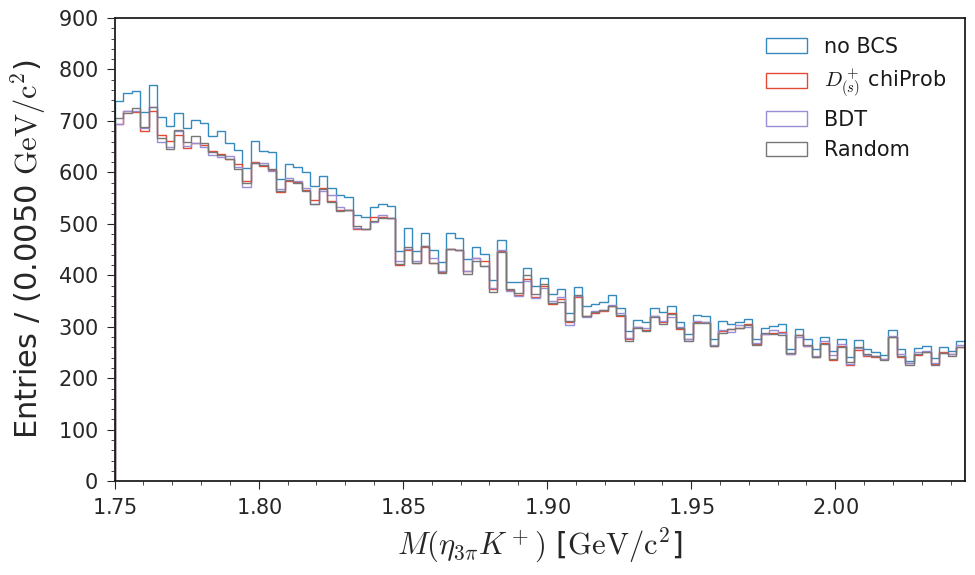

In [16]:
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_BCS_comparison_fitv12.png")


fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, nbins+1)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(combined_mc_data_BDT_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_BDT_BCS.ds_weight,label='BDT');
plt.hist(combined_mc_data_random_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_random_BCS.ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(rf"Entries / ({bin_width:.4f} $\mathrm{{GeV/c^2}}$)")
plt.tight_layout()
plt.savefig(output)

In [19]:
mc_data_Dp_chiProb_BCS = load_root_files('Dp_chiProb', mc_topo_dirs, mc_dirs, tags, tree, cut, variables, bdt_cut)
combined_mc_data_Dp_chiProb_BCS = pd.concat(mc_data_Dp_chiProb_BCS.values(), ignore_index=True, sort=False)


ccbar: 5 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_all_bkg_etapip_component_fitv12.png


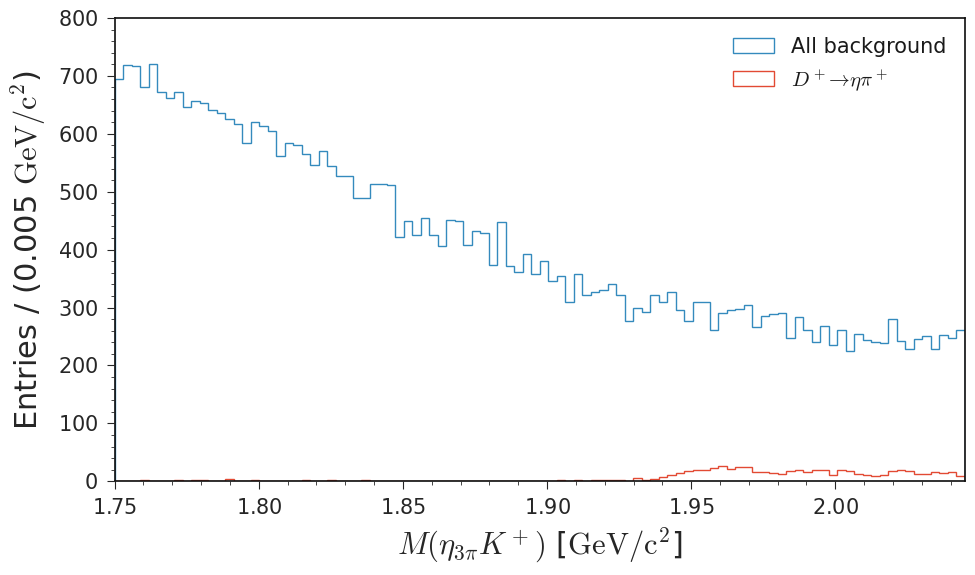

In [20]:
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_all_bkg_etapip_component_fitv12.png")

cut = "nAllSigCascDcyBr_4>0"

fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, nbins+1)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'All background');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query(cut).Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query(cut).ds_weight,label=r'$D^+ \to \eta \pi^+$');

plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(rf"Entries / ({bin_width:.3f} $\mathrm{{GeV/c^2}}$)")
plt.tight_layout()
plt.savefig(output)
print(output)

/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_all_bkg_etapip_component_Dp_Ds_fitv12.png


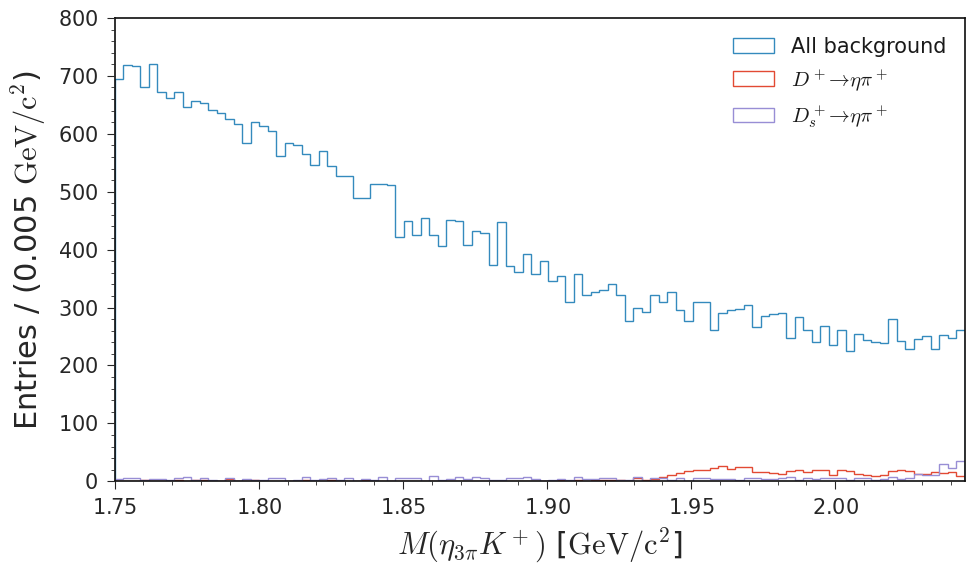

In [22]:
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_all_bkg_etapip_component_Dp_Ds_fitv12.png")
cut1 = "nAllSigCascDcyBr_4>0"

cut2 = "nAllSigCascDcyBr_8>0"

fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, nbins+1)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'All background');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query(cut1).Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query(cut1).ds_weight,label=r'$D^+ \to \eta \pi^+$');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query(cut2).Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query(cut2).ds_weight,label=r'$D^+_s \to \eta \pi^+$');

plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(rf"Entries / ({bin_width:.3f} $\mathrm{{GeV/c^2}}$)")
plt.tight_layout()
plt.savefig(output)
print(output)

/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_etapip_component_Dp_Ds_fitv12.png


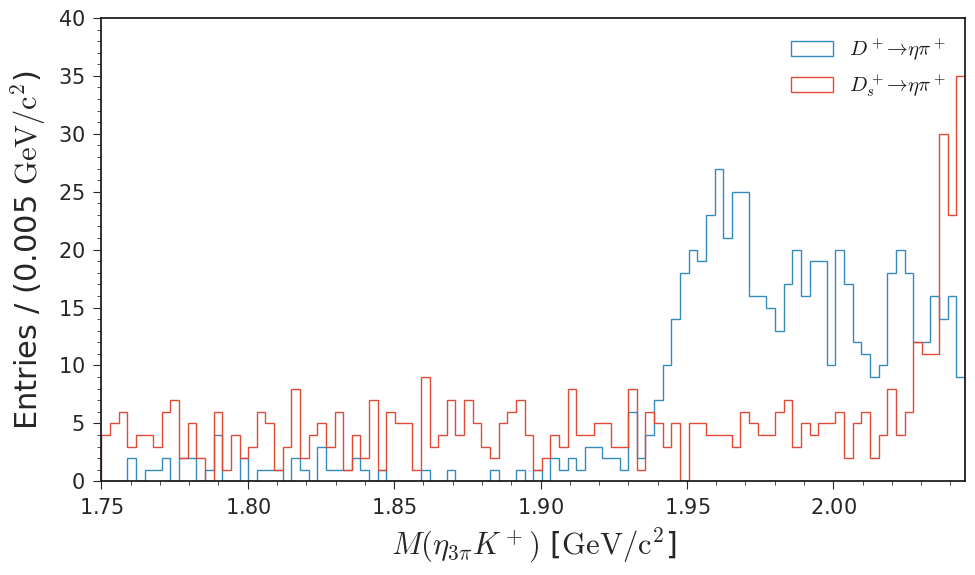

In [24]:
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_etapip_component_Dp_Ds_fitv12.png")
cut1 = "nAllSigCascDcyBr_4>0"

cut2 = "nAllSigCascDcyBr_8>0"

fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, nbins+1)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
# plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'All background');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query(cut1).Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query(cut1).ds_weight,label=r'$D^+ \to \eta \pi^+$');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query(cut2).Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query(cut2).ds_weight,label=r'$D^+_s \to \eta \pi^+$');

plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(rf"Entries / ({bin_width:.3f} $\mathrm{{GeV/c^2}}$)")
plt.tight_layout()
plt.savefig(output)
print(output)